# Análise de séries temporais

## Entendendo o problema

Uma rede de restaurantes está com dificuldades em realizar o planejamento do negócio como um todo. A percepção é de que em alguns dias o movimento é muito baixo, fazendo com que os garçons fiquem muito ociosos. Em outros dias, o movimento é muito alto, e a quantidade de garçons parece ser insuficiente para atender a todas as pessoas.

Vamos realizar uma análise nos dados de **quantidade de clientes por dia nos restaurantes** para melhorar o planejamento de atendimento na rede de restaurantes.

### Fazendo a leitura dos dados

O primeiro passo é fazer a leitura da base de dados, a partir do arquivo `qtd_clientes_restaurantes.csv`. Vamos fazer a leitura com a função [`read_csv()`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) da biblioteca `pandas`.

In [1]:
import pandas as pd


In [2]:
dados = pd.read_csv('/Users/thaisfernandespereira/Documents/estat_analises-1/series_temporais/clientes_restaurantes.csv')

In [3]:
dados

,data,Chimi & Churri,Assa Frão
0,1/1/2016,65.0,139.0
1,1/2/2016,24.0,85.0
2,1/3/2016,24.0,81.0
3,1/4/2016,23.0,32.0
4,1/5/2016,2.0,43.0
...,...,...,...
473,4/18/2017,30.0,18.0
474,4/19/2017,20.0,18.0
475,4/20/2017,22.0,46.0
476,4/21/2017,38.0,38.0


O `DataFrame` apresenta informações de data e quantidade de clientes de dois restaurantes ao longo dos dias, o **Chimi & Churri** e o **Assa Frão**. Precisamos fazer uma análise desses dados de restaurante para aprimorar o planejamento da quantidade de garçons que precisam ser alocados em cada dia.

Vamos ver algumas informações adicionais dos dados, como presença de dados nulos e tipos de dados em cada coluna, usando o método [`info()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html).

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            478 non-null    object 
 1   Chimi & Churri  476 non-null    float64
 2   Assa Frão       477 non-null    float64
dtypes: float64(2), object(1)
memory usage: 11.3+ KB


A coluna `data` é do tipo `object`, portanto está sendo entendida como um texto. Vamos aplicar uma transformação da coluna para o formato `datetime` e definir essa informação como o índice do `DataFrame`.

In [5]:
dados['data'] = pd.to_datetime(dados['data'])

dados.set_index('data', inplace = True)

In [6]:
dados

,Chimi & Churri,Assa Frão
data,,
2016-01-01,65.0,139.0
2016-01-02,24.0,85.0
2016-01-03,24.0,81.0
2016-01-04,23.0,32.0
2016-01-05,2.0,43.0
...,...,...
2017-04-18,30.0,18.0
2017-04-19,20.0,18.0
2017-04-20,22.0,46.0


A base de dados já está carregada e já possui os dados de data como sendo o índice do `DataFrame`.

### Encontrando dados nulos

In [7]:
dados['Chimi & Churri'][dados['Chimi & Churri'].isna()]

data
2016-04-05   NaN
2016-09-17   NaN
Name: Chimi & Churri, dtype: float64

Visualizando os nulos com um gráfico

In [8]:
import matplotlib.pyplot as plt

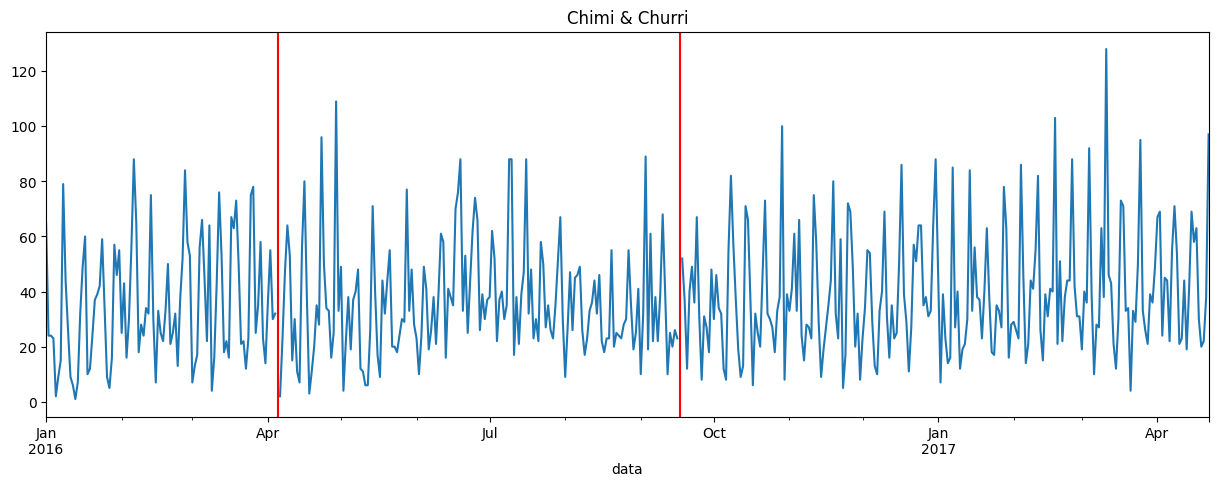

In [9]:
dados['Chimi & Churri'].plot(figsize = (15, 5), title = 'Chimi & Churri')
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isna()].index[0], color = 'red')
plt.axvline(x = dados['Chimi & Churri'][dados['Chimi & Churri'].isna()].index[1], color = 'red');

In [10]:
dados['Assa Frão'][dados['Assa Frão'].isna()]

data
2016-11-24   NaN
Name: Assa Frão, dtype: float64

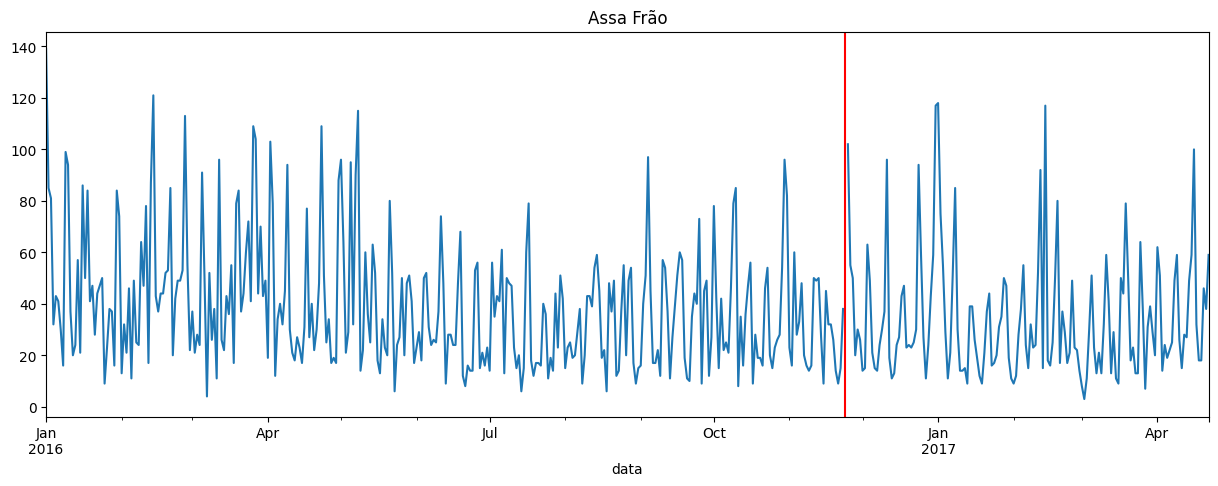

In [11]:
dados['Assa Frão'].plot(figsize = (15, 5), title = 'Assa Frão')
plt.axvline(x = dados['Assa Frão'][dados['Assa Frão'].isna()].index[0], color = 'red')

### Tratando dados nulos

Em séries temporais algumas opções são: 

1. preencher com o valor anterior
2. preencher com o valor posterior
3. preencher com o ponto médio do valor anterior e posterior

In [12]:
# Vamos usar a opção 3: preencher com o ponto médio do valor anterior e posterior
# Método interpolate para preencher os valores nulos com base nos valores vizinhos

dados = dados.interpolate()

In [13]:
# verificando se funcionou, se não houver mais valores nulos, o método funcionou corretamente

dados.loc['2016-04-04':'2016-04-06']

,Chimi & Churri,Assa Frão
data,,
2016-04-04,32.0,12.0
2016-04-05,17.0,34.0
2016-04-06,2.0,40.0


In [14]:
dados.loc['2016-09-16':'2016-09-18']

,Chimi & Churri,Assa Frão
data,,
2016-09-16,23.0,51.0
2016-09-17,37.5,60.0
2016-09-18,52.0,57.0


In [15]:
dados.loc['2016-11-23':'2016-11-25']

,Chimi & Churri,Assa Frão
data,,
2016-11-23,5.0,38.0
2016-11-24,17.0,70.0
2016-11-25,72.0,102.0


### Explorando os dados

Visualizando a distribuição com histograma, bloxplot e describe

In [16]:
# Os dos estão como decimais mas queremos que eles sejam inteiros, então vamos converter para int

dados = dados.astype(int)
dados

,Chimi & Churri,Assa Frão
data,,
2016-01-01,65,139
2016-01-02,24,85
2016-01-03,24,81
2016-01-04,23,32
2016-01-05,2,43
...,...,...
2017-04-18,30,18
2017-04-19,20,18
2017-04-20,22,46


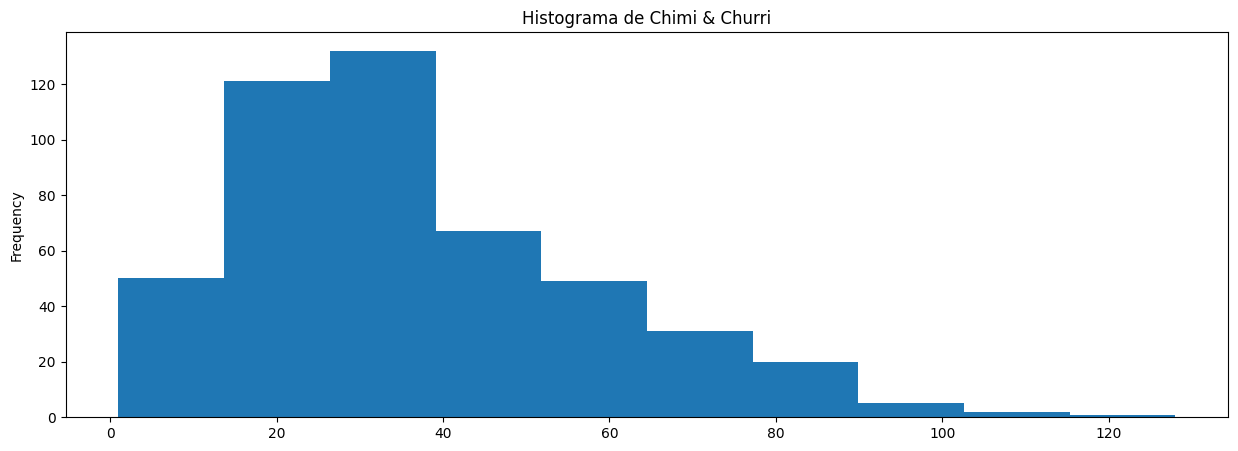

In [17]:
dados['Chimi & Churri'].plot(kind = 'hist', title = 'Histograma de Chimi & Churri', figsize = (15, 5)); 

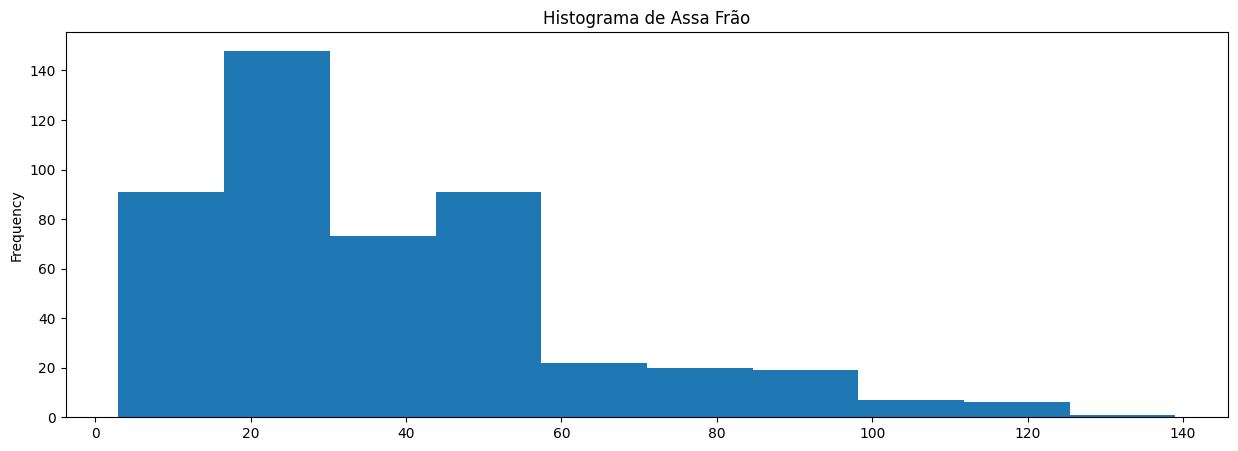

In [18]:
dados['Assa Frão'].plot(kind = 'hist', title = 'Histograma de Assa Frão', figsize = (15, 5)); 

In [19]:
dados.describe()

,Chimi & Churri,Assa Frão
count,478.000000,478.000000
mean,37.451883,37.679916
std,21.433061,24.619708
min,1.000000,3.000000
25%,22.250000,19.000000
50%,33.000000,30.500000
75%,49.000000,50.000000
max,128.000000,139.000000


<Axes: title={'center': 'Boxplots da quantidade de clientes por restaurante'}>

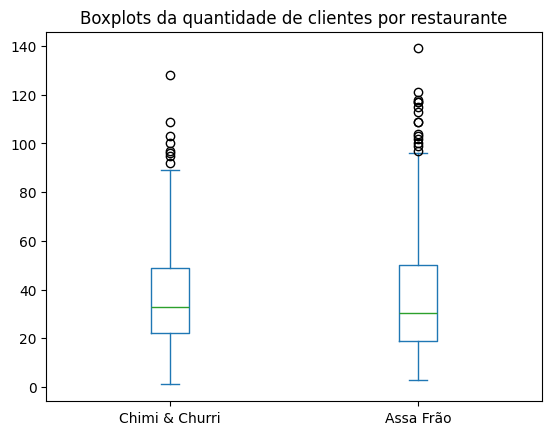

In [20]:
dados.plot(kind = 'box', title = 'Boxplots da quantidade de clientes por restaurante')

Contabilizando o total de clientes

In [21]:
dados.sum(axis = 1)

data
2016-01-01    204
2016-01-02    109
2016-01-03    105
2016-01-04     55
2016-01-05     45
             ... 
2017-04-18     48
2017-04-19     38
2017-04-20     68
2017-04-21     76
2017-04-22    156
Length: 478, dtype: int64

In [22]:
dados['Total'] = dados.sum(axis = 1)

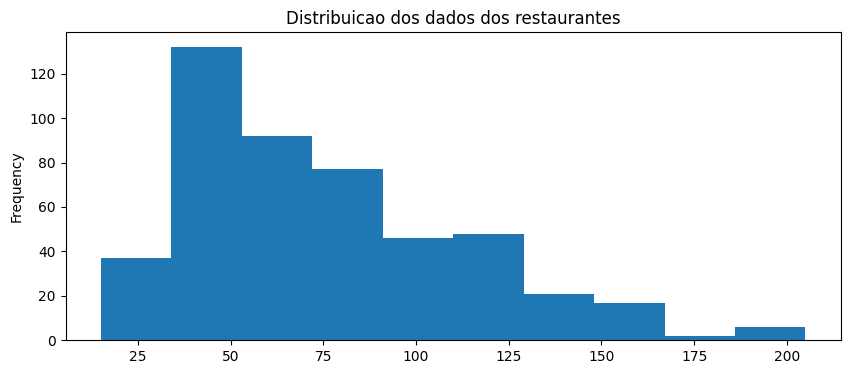

In [23]:
dados['Total'].plot(kind = 'hist', title = 'Distribuicao dos dados dos restaurantes', figsize = (10,4));

In [24]:
dados.describe()

,Chimi & Churri,Assa Frão,Total
count,478.000000,478.000000,478.000000
mean,37.451883,37.679916,75.131799
std,21.433061,24.619708,37.512896
min,1.000000,3.000000,15.000000
25%,22.250000,19.000000,45.000000
50%,33.000000,30.500000,66.500000
75%,49.000000,50.000000,99.000000
max,128.000000,139.000000,205.000000


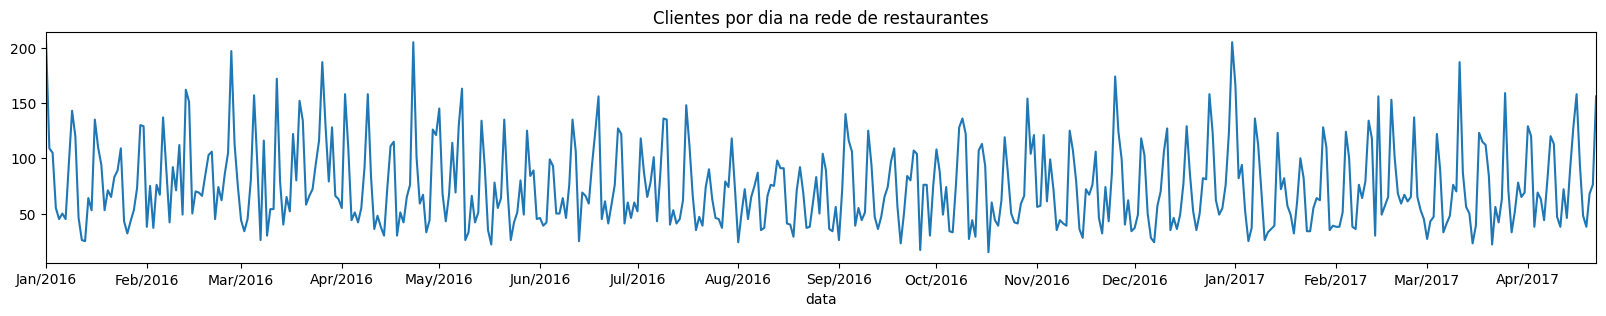

In [26]:
# grafico mostrando todos os meses

from matplotlib import dates

ax = dados['Total'].plot(figsize= (20,3), title = 'Clientes por dia na rede de restaurantes')

ax.xaxis.set_major_locator(dates.MonthLocator())
ax.xaxis.set_major_formatter(dates.DateFormatter('%b/%Y'));



Como os valores variam muito ao longo do mês, vamos fazer um agrupamento dos dados para entender se existe uma diferença significativa em cada mês

Sobre o método resample: permite a reamostragem de dados com base em informações de tempo, Isso envolve a agregação de dados em uma frequência mais baixa, por exemplo transformar dados diários em mensais, ou a interpolação de dados para uma frequência mais alta, por exemplo transformar dados mensais em diários.


In [27]:
clientes_mensais = dados.resample(rule = 'M')[['Chimi & Churri', 'Assa Frão']].sum()

clientes_mensais

/var/folders/x8/b89wn3vx0jd4cmv6h5_4cv6m0000gn/T/ipykernel_1486/3069998093.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  clientes_mensais = dados.resample(rule = 'M')[['Chimi & Churri', 'Assa Frão']].sum()


,Chimi & Churri,Assa Frão
data,,
2016-01-31,920,1577
2016-02-29,1109,1396
2016-03-31,1177,1513
2016-04-30,1089,1229
2016-05-31,957,1338
2016-06-30,1262,914
2016-07-31,1299,986
2016-08-31,972,944
2016-09-30,1037,1084


In [28]:
clientes_mensais.index.month_name(locale = 'pt_PT.ISO8859-1').map(lambda mes: 'Março' if mes == '' else mes)

Index(['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho',
       'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro', 'Janeiro',
       'Fevereiro', 'Março', 'Abril'],
      dtype='object', name='data')

In [29]:
clientes_mensais['M'] = clientes_mensais.index.month_name(locale = 'pt_PT.ISO8859-1').map(lambda mes: 'Março' if mes == '' else mes)

clientes_mensais

,Chimi & Churri,Assa Frão,M
data,,,
2016-01-31,920,1577,Janeiro
2016-02-29,1109,1396,Fevereiro
2016-03-31,1177,1513,Março
2016-04-30,1089,1229,Abril
2016-05-31,957,1338,Maio
2016-06-30,1262,914,Junho
2016-07-31,1299,986,Julho
2016-08-31,972,944,Agosto
2016-09-30,1037,1084,Setembro


/var/folders/x8/b89wn3vx0jd4cmv6h5_4cv6m0000gn/T/ipykernel_1486/1743283070.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.xaxis.set_minor_formatter(ticker.FixedFormatter(['\n\n2016', '\n\n2017']))


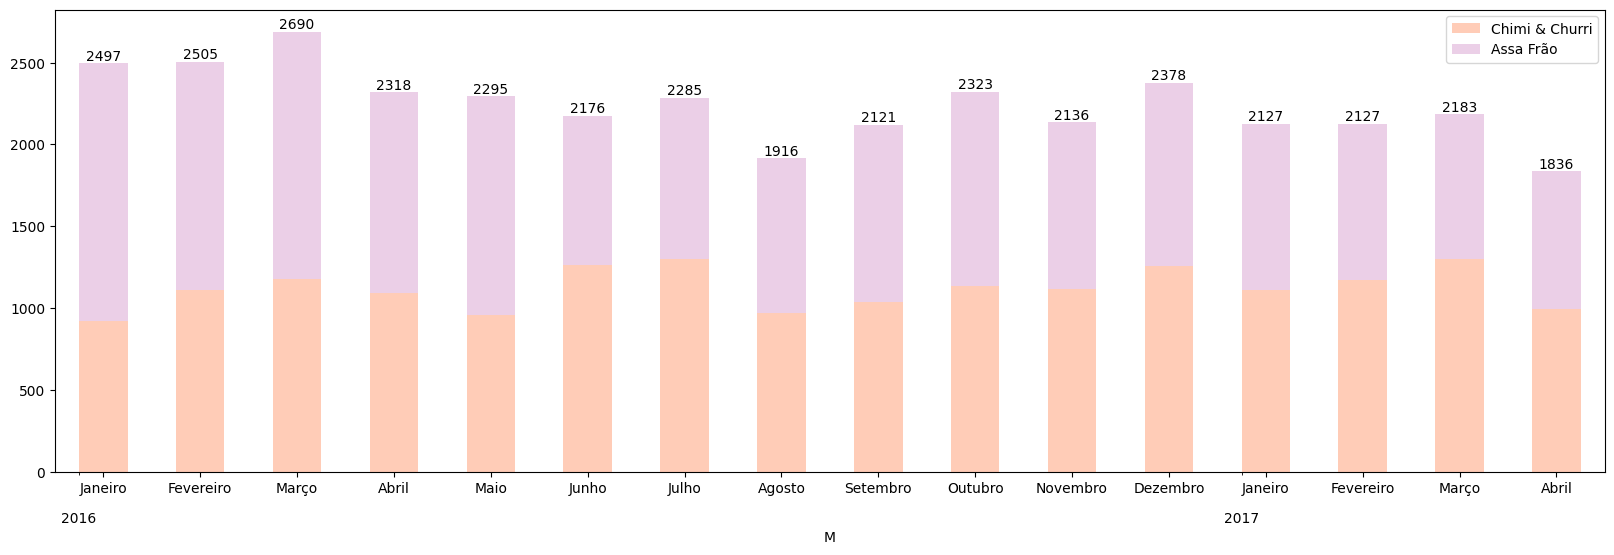

In [30]:
ax = clientes_mensais.plot(x = 'M', kind = 'bar', stacked = True, color = ['#ffccb7', '#ebcfe7'], rot = 0, figsize= (20,6))

import matplotlib.ticker as ticker

ax.bar_label(ax.containers[1], fontsize = 10)
ax.xaxis.set_minor_locator(ticker.IndexLocator(12,0))
ax.xaxis.set_minor_formatter(ticker.FixedFormatter(['\n\n2016', '\n\n2017']))


### Extraindo médias móveis

In [31]:
for restaurante in ['Chimi & Churri', 'Assa Frão']:
    dados[f'{restaurante}_MM7'] = dados[[restaurante]].rolling(7).mean()

In [32]:
dados

,Chimi & Churri,Assa Frão,Total,Chimi & Churri_MM7,Assa Frão_MM7
data,,,,,
2016-01-01,65,139,204,NaN,NaN
2016-01-02,24,85,109,NaN,NaN
2016-01-03,24,81,105,NaN,NaN
2016-01-04,23,32,55,NaN,NaN
2016-01-05,2,43,45,NaN,NaN
...,...,...,...,...,...
2017-04-18,30,18,48,46.285714,44.714286
2017-04-19,20,18,38,42.857143,43.285714
2017-04-20,22,46,68,43.285714,46.000000


In [33]:
import plotly.express as px

px.line(dados, 
        x = dados.index,
        y = ['Chimi & Churri_MM7', 'Assa Frão_MM7'], 
        width= 1150,
        height= 400,
        title= "Média móvel de 7 dias da quantidade de clientes na rede de restaurantes")



Analisando a média móvel como tendência

Vamos observar como se comporta a média movel em relacao a serie temporal original

A média móvel é uma técnica que suaviza as flutuações de curto prazo e destaca tendências de longo prazo, sendo ideal para confirmar a tendência de crescimento observada nos meses de verão.

Tipos de médias móveis
Existem vários tipos de médias móveis, sendo as mais comuns:

1 - Média móvel simples: É a média aritmética calculada em um período predeterminado. Como exemplo, uma média móvel simples de 5 dias é a soma dos valores de 5 dias dividida por 5.

2 - Média móvel exponencial: O cálculo dá mais peso aos valores mais recentes, tornando-a mais sensível a novas informações.

3 - Média móvel ponderada: Dá pesos diferentes aos valores dentro de um período, multiplicando cada valor por um peso específico e somando os resultados.

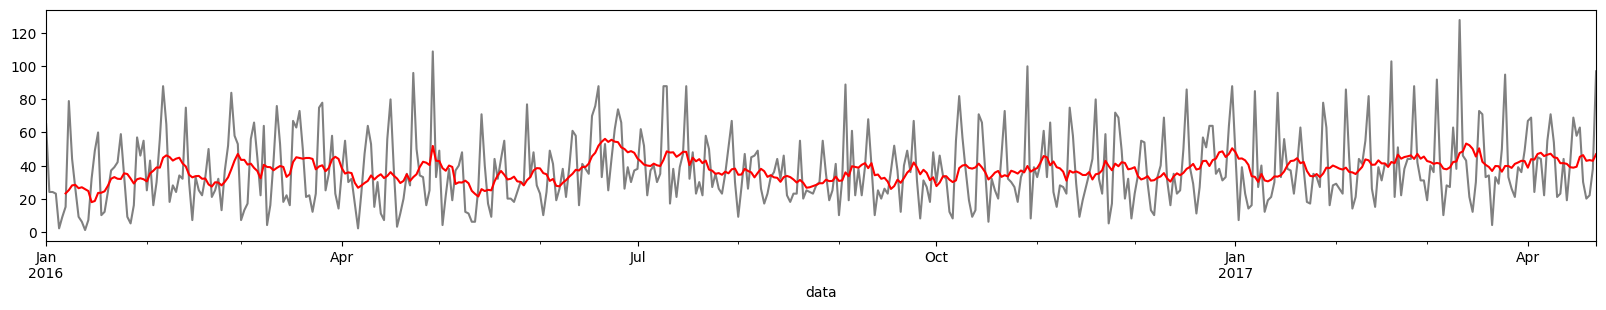

In [34]:
dados['Chimi & Churri'].plot(color = 'gray', figsize = (20,3))
dados['Chimi & Churri_MM7'].plot(color = 'red', figsize = (20,3));

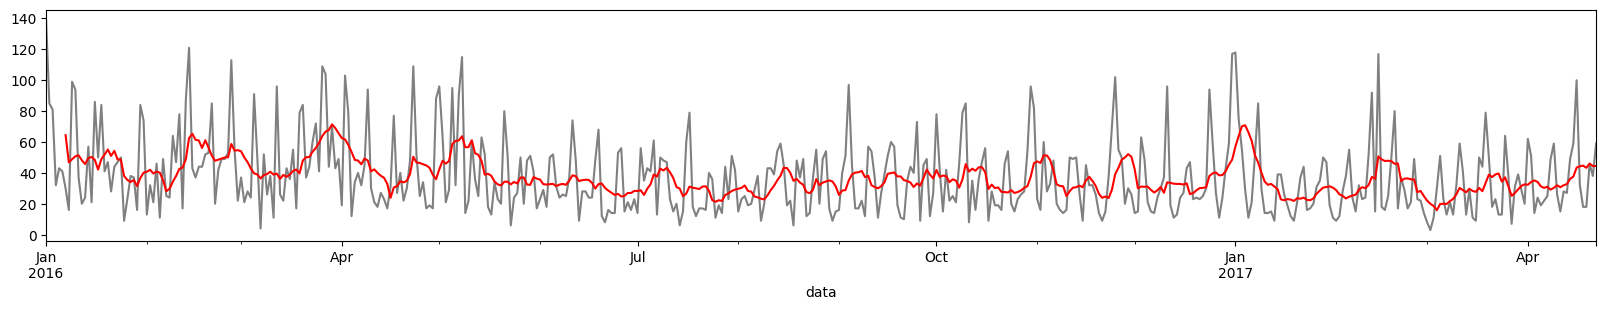

In [35]:
dados['Assa Frão'].plot(color = 'gray', figsize = (20,3))
dados['Assa Frão_MM7'].plot(color = 'red', figsize = (20,3));

### Detectando Anomalias

In [42]:
dados.index.day_name(locale = 'pt_BR.UTF-8')

dados['Dia da semana'] = dados.index.day_name(locale = 'pt_BR.UTF-8')

In [52]:
caminho_csv = "/Users/thaisfernandespereira/Documents/estat_analises-1/series_temporais/datas_comemorativas.csv"

datas_comemorativas = pd.read_csv(caminho_csv)

datas_comemorativas['data'] = pd.to_datetime(datas_comemorativas['data'])
datas_comemorativas = datas_comemorativas.set_index('data', drop = True)
datas_comemorativas

,feriado
data,
2016-01-01,Ano novo
2016-02-14,Dia dos namorados
2016-03-25,Sexta-feira santa
2016-03-27,Pascoa
2016-03-28,Domingo de pascoa
2016-05-08,Dia das maes
2016-06-19,Dia dos pais
2016-10-31,Halloween
2016-11-25,Black Friday


In [53]:
dados = pd.merge(dados, datas_comemorativas, how = 'left', left_index = True, right_index = True)

dados

,Chimi & Churri,Assa Frão,Total,Chimi & Churri_MM7,Assa Frão_MM7,Dia da semana,feriado
data,,,,,,,
2016-01-01,65,139,204,NaN,NaN,Sexta feira,Ano novo
2016-01-02,24,85,109,NaN,NaN,Sábado,NaN
2016-01-03,24,81,105,NaN,NaN,Domingo,NaN
2016-01-04,23,32,55,NaN,NaN,Segunda feira,NaN
2016-01-05,2,43,45,NaN,NaN,Terça feira,NaN
...,...,...,...,...,...,...,...
2017-04-18,30,18,48,46.285714,44.714286,Terça feira,NaN
2017-04-19,20,18,38,42.857143,43.285714,Quarta feira,NaN
2017-04-20,22,46,68,43.285714,46.000000,Quinta feira,NaN


### Capturando dados discrepantes

Os dados discrepantes serao capturados por meio do desvio-padrao dos dados. 

O z-score (ou escore Z) é uma medida estatística que indica quantos desvios padrão um valor está distante da média. 

Em Python, você pode calculá-lo facilmente usando bibliotecas como SciPy ou NumPy para padronizar dados e achar erros ou valores estranhos.

O que o Z-Score faz? 

Mede a distância: Mostra se um número está acima, abaixo ou igual à média dos dados.

Padroniza valores: Transforma os dados para uma escala onde a média vira 0 e o desvio padrão vira 1.

Acha outliers: Ajuda a achar valores muito distantes do normal (geralmente quando o resultado é maior que 3 ou menor que -3)

In [56]:
from scipy.stats import zscore

def detectar_anomalias(coluna):
    dados['zscore'] = zscore(dados[coluna])
    anomalias = dados[(dados['zscore']>3) | (dados['zscore']<-3)]
    return anomalias[[coluna, 'zscore', 'Dia da semana', 'feriado']]

In [57]:
anomalias_chimi_churri = detectar_anomalias('Chimi & Churri')

anomalias_assa_frao = detectar_anomalias('Assa Frão')

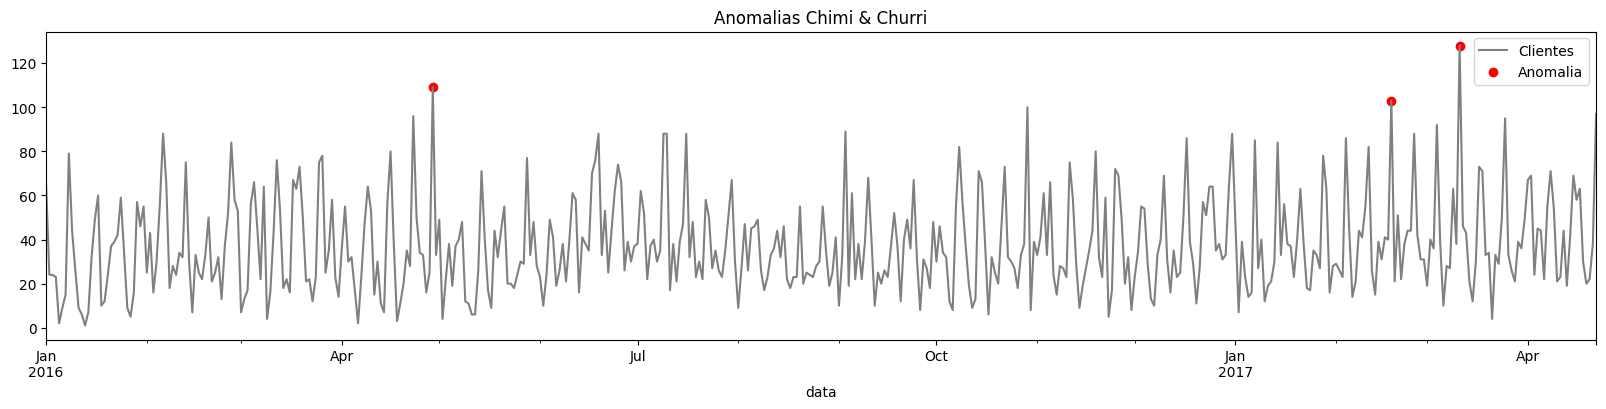

In [58]:
ax = dados['Chimi & Churri'].plot(label = 'Clientes', color = 'gray', figsize = (20,4))
ax.scatter(anomalias_chimi_churri.index.to_pydatetime(), anomalias_chimi_churri['Chimi & Churri'], color = 'red', label = 'Anomalia')
ax.set_title('Anomalias Chimi & Churri')
ax.legend();

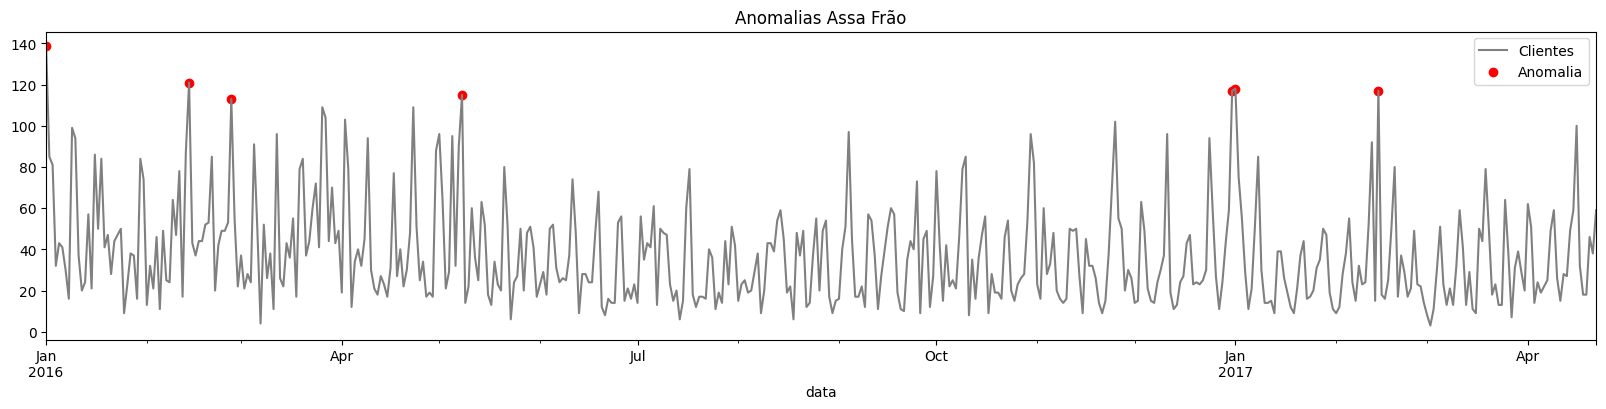

In [59]:
ax = dados['Assa Frão'].plot(label = 'Clientes', color = 'gray', figsize = (20,4))
ax.scatter(anomalias_assa_frao.index.to_pydatetime(), anomalias_assa_frao['Assa Frão'], color = 'red', label = 'Anomalia')
ax.set_title('Anomalias Assa Frão')
ax.legend();

In [62]:
print('Anomalias para o Chimi & Churri')
display(anomalias_chimi_churri)
print('\n\n')
print('Anomalias para o Assa Frão')
display(anomalias_assa_frao)

Anomalias para o Chimi & Churri


,Chimi & Churri,zscore,Dia da semana,feriado
data,,,,
2016-04-29,109,3.341710,Sexta feira,NaN
2017-02-18,103,3.061475,Sábado,NaN
2017-03-11,128,4.229120,Sábado,NaN





Anomalias para o Assa Frão


,Assa Frão,zscore,Dia da semana,feriado
data,,,,
2016-01-01,139,4.119717,Sexta feira,Ano novo
2016-02-14,121,3.387830,Domingo,Dia dos namorados
2016-02-27,113,3.062546,Sábado,NaN
2016-05-08,115,3.143867,Domingo,Dia das maes
2016-12-31,117,3.225188,Sábado,Vespera de ano novo
2017-01-01,118,3.265848,Domingo,Ano novo
2017-02-14,117,3.225188,Terça feira,Dia dos namorados
